<a href="https://colab.research.google.com/github/koniitinomiya-prog/crack-detection/blob/main/Crack_detection_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crack Detection CNN

コンクリートのひび割れ検出を行うCNNモデルです。

授業のFashion MNISTと同じ流れで実装します：
1. Data Prep
2. Define Model
3. Set Optimization Parameters
4. Train Model
5. Evaluate Model

**データセット**: SDNET2018
- 56,000枚以上のコンクリート画像（ひびあり／なし）
- Bridge decks (D), Walls (W), Pavements (P)
- 各画像は256×256px


# VS Codeで編集テスト

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

zip_path    = "/content/drive/MyDrive/HODL/SDNET2018.zip"
extract_dir = "/content/D"   # ZIPはトップレベルフォルダなしで展開される

if not os.path.exists(extract_dir):
    print("Extracting zip...")
    with zipfile.ZipFile(zip_path, 'r') as zf:
        zf.extractall("/content")
    print("Done!")
else:
    print("Already extracted.")

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
import os, shutil
from pathlib import Path

# 再現性のためにシードを固定（授業と同じ）
keras.utils.set_random_seed(42)

print("TensorFlow version:", tf.__version__)
print("GPU available:", len(tf.config.list_physical_devices('GPU')) > 0)

In [ ]:
# ★ 割合を変更したい場合はここだけ編集
TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
# TEST_RATIO  = 残り (1 - TRAIN_RATIO - VAL_RATIO)

src_dir  = Path("/content/D")          # ZIP解凍後のパス
base_dir = Path("/content/crack-data")

class_map = {
    "CD": "cracked",    # Cracked Deck
    "UD": "uncracked",  # Uncracked Deck
}

for src_folder, label in class_map.items():
    fnames = sorted(os.listdir(src_dir / src_folder))
    n = len(fnames)

    n_train = int(n * TRAIN_RATIO)
    n_val   = int(n * VAL_RATIO)

    splits = {
        "train":      fnames[:n_train],
        "validation": fnames[n_train : n_train + n_val],
        "test":       fnames[n_train + n_val :],
    }

    for split, names in splits.items():
        dst_dir = base_dir / split / label
        os.makedirs(dst_dir, exist_ok=True)
        for fname in names:
            shutil.copyfile(
                src=src_dir / src_folder / fname,
                dst=dst_dir / fname
            )

for split in ("train", "validation", "test"):
    for label in ("cracked", "uncracked"):
        n = len(list((base_dir / split / label).glob("*.jpg")))
        print(f"{split}/{label}: {n} images")

In [ ]:
IMG_SIZE = 64

train_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'train',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32)

validation_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'validation',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32)

test_dataset = keras.utils.image_dataset_from_directory(
    base_dir / 'test',
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=32)

# クラス名確認（アルファベット順: cracked=0, uncracked=1）
print("Class names:", train_dataset.class_names)

# 正規化 (0-255 → 0-1) とラベル反転（cracked=1, uncracked=0 に統一）
# image_dataset_from_directory はアルファベット順でラベルを付けるため
# "cracked"=0, "uncracked"=1 となるので 1 - labels で反転する
def preprocess(images, labels):
    return images / 255.0, 1 - labels

train_dataset      = train_dataset.map(preprocess)
validation_dataset = validation_dataset.map(preprocess)
test_dataset       = test_dataset.map(preprocess)

In [ ]:
# ひびあり・なしを10枚ずつ表示
labels_map = ["Non-cracked", "Cracked"]
N = 10

# 10枚ずつ集まるまで複数バッチから収集
cracked_imgs, noncracked_imgs = [], []
for images, batch_labels in train_dataset:
    for img, lbl in zip(images.numpy(), batch_labels.numpy()):
        if lbl == 1 and len(cracked_imgs) < N:
            cracked_imgs.append(img)
        elif lbl == 0 and len(noncracked_imgs) < N:
            noncracked_imgs.append(img)
    if len(cracked_imgs) >= N and len(noncracked_imgs) >= N:
        break

sample_imgs   = noncracked_imgs + cracked_imgs
sample_labels = [0] * N + [1] * N

figure = plt.figure(figsize=(20, 4))
for i, (img, lbl) in enumerate(zip(sample_imgs, sample_labels)):
    ax = figure.add_subplot(2, N, i+1, xticks=[], yticks=[])
    ax.imshow(img)
    ax.set_title(labels_map[lbl])
plt.suptitle("Sample Training Images")
plt.tight_layout()
plt.show()

## 2. Define Model

授業のFashion MNISTとほぼ同じ構造です。

違いは：
- 入力: `(64, 64, 3)` ← カラー画像（RGBの3チャンネル）
- 出力: `Dense(1, sigmoid)` ← 2クラス分類（ひびあり／なし）

```
Fashion MNIST:   Dense(10, softmax)  ← 10クラス分類
Crack Detection: Dense(1, sigmoid)   ← 2クラス分類
```

In [ ]:
input = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))  # (64, 64, 3)

# ==============================
# 【追加】Data Augmentation
# 訓練時だけランダムに画像を変形して水増しする
# → 同じ画像を何度も見せず過学習を防ぐ
# ※ model.predict()時は自動でOFFになる
# ==============================
x = keras.layers.RandomFlip("horizontal_and_vertical")(input)  # 左右・上下反転
x = keras.layers.RandomRotation(0.15)(x)                       # ±15%回転
x = keras.layers.RandomZoom(0.1)(x)                            # ±10%拡縮

# ==============================
# 第1 Conv Block
# ==============================
x = keras.layers.Conv2D(32, (3,3), padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D()(x)

# ==============================
# 第2 Conv Block
# ==============================
x = keras.layers.Conv2D(64, (3,3), padding="same")(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Activation("relu")(x)
x = keras.layers.MaxPool2D()(x)

# ==============================
# 全結合層
# ==============================
x = keras.layers.Flatten()(x)
x = keras.layers.Dense(256, activation="relu")(x)
x = keras.layers.Dropout(0.5)(x)

# ==============================
# 出力層（sigmoid: 0〜1の確率を出力、0.5以上→ひびあり）
# ==============================
output = keras.layers.Dense(1, activation="sigmoid")(x)

model = keras.Model(input, output)
model.summary()

## 3. Set Optimization Parameters

授業との違い：
- 損失関数: `binary_crossentropy`（2クラスなのでbinary）
  - 授業: `sparse_categorical_crossentropy`（10クラス）
- メトリクス: `accuracy` に加えて `Recall` も監視

In [ ]:
# 授業と同じplot関数（loss と accuracy）
def plot_loss_curves(history):
    plt.clf()
    plt.plot(history.history["loss"],     "bo", label="Training loss")
    plt.plot(history.history["val_loss"], "b",  label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

def plot_acc_curves(history):
    plt.clf()
    plt.plot(history.history["accuracy"],     "bo", label="Training acc")
    plt.plot(history.history["val_accuracy"], "b",  label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

def plot_recall_curves(history):
    plt.clf()
    plt.plot(history.history["recall"],     "ro", label="Training recall")
    plt.plot(history.history["val_recall"], "r",  label="Validation recall")
    plt.axhline(y=0.95, color='gray', linestyle='--', label="Target (0.95)")
    plt.title("Training and validation recall")
    plt.xlabel("Epochs")
    plt.ylabel("Recall")
    plt.legend()
    plt.show()

In [ ]:
model.compile(
    loss='binary_crossentropy',
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    metrics=[
        'accuracy',
        keras.metrics.Recall(name='recall'),       # ひび割れの見逃し率監視
        keras.metrics.Precision(name='precision')  # 誤検出率監視
    ]
)

In [ ]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    train_dataset,
    epochs=30,
    validation_data=validation_dataset,
    callbacks=[early_stop]
)

## 4. Train the Model

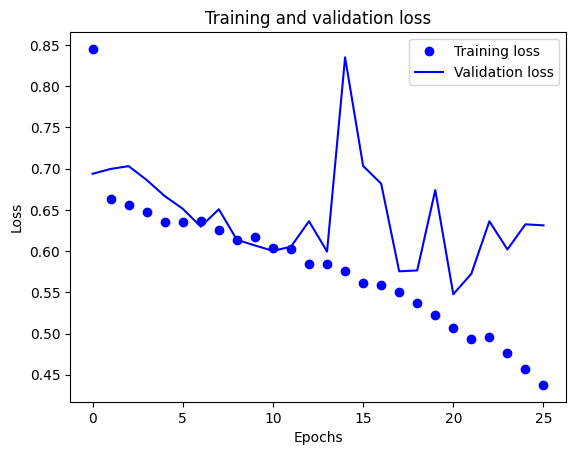

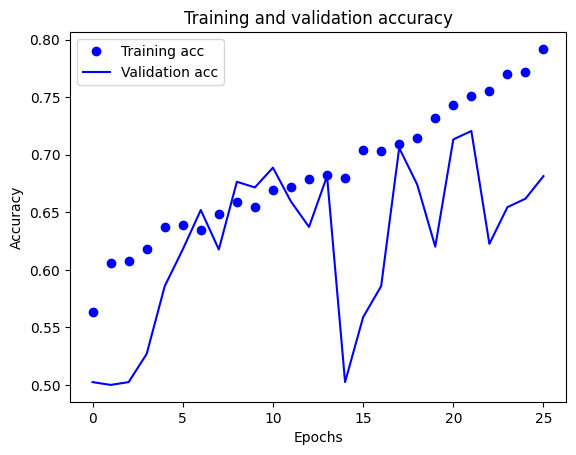

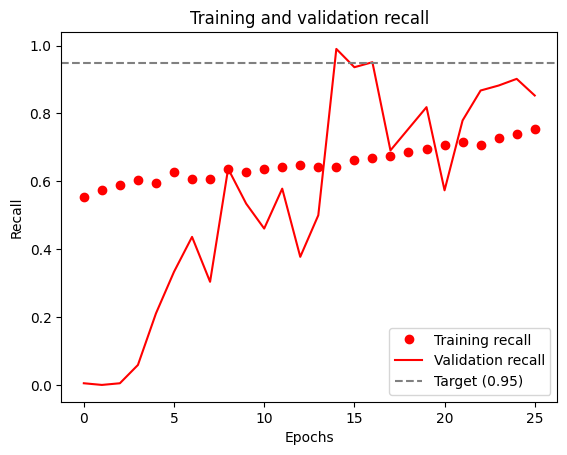

In [ ]:
# 授業と同じ：lossとaccuracyのグラフ
plot_loss_curves(history)
plot_acc_curves(history)

# ひび割れ検出特有：Recallのグラフ
plot_recall_curves(history)

## 5. Evaluate the Model

In [ ]:
# 授業と同じ：model.evaluate()
score = model.evaluate(test_dataset)
print("Test loss:     ", score[0])
print("Test accuracy: ", score[1])
print("Test recall:   ", score[2])
print("Test precision:", score[3])

In [ ]:
# データセットから正解ラベルと予測結果を収集
y_prob = model.predict(test_dataset).flatten()
y_pred = (y_prob >= 0.5).astype(int)

# データセットから真のラベルを収集
y_test = np.concatenate([y.numpy() for _, y in test_dataset])
x_test_list = [x.numpy() for x, _ in test_dataset]
x_test = np.concatenate(x_test_list)

misses = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(misses)} / {len(y_test)} images")

In [ ]:
# 間違えた画像を表示（授業と同じスタイル）
sample = np.random.choice(misses, size=min(8, len(misses)), replace=False)
figure = plt.figure(figsize=(16, 4))
for i, idx in enumerate(sample):
    ax = figure.add_subplot(2, 4, i+1, xticks=[], yticks=[])
    ax.imshow(x_test[idx])
    ax.set_title("{} ({})".format(
        labels_map[y_pred[idx]],
        labels_map[y_test[idx]]
    ))
plt.suptitle("Misclassified: Predicted (Actual)")
plt.tight_layout()
plt.show()

## 6. Bonus: ヒートマップで「どこにひびがあるか」を可視化

大きな壁の写真を256×256に切り分けて、ひびがある場所をヒートマップで表示します。

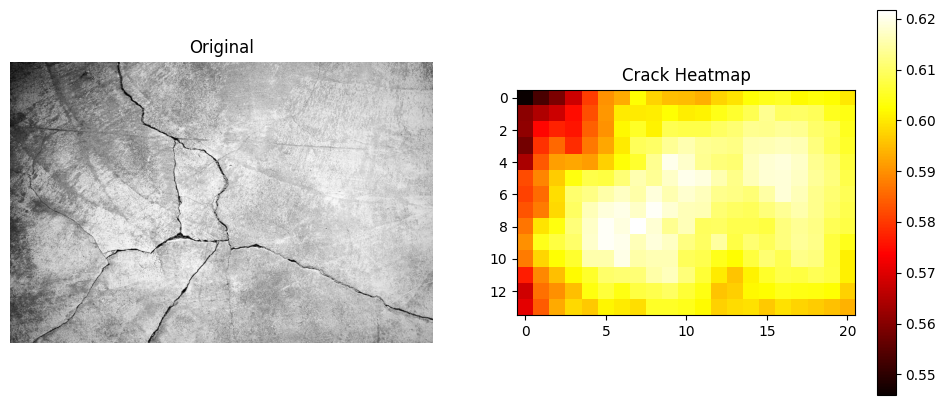

In [ ]:
import math
from PIL import Image

def crack_heatmap(image_path, model, tile=64, stride=16):
    img = Image.open(image_path).convert("RGB")
    W, H = img.size

    nx = math.floor((W - tile) / stride) + 1
    ny = math.floor((H - tile) / stride) + 1
    heat = np.zeros((ny, nx), dtype=np.float32)

    for iy in range(ny):
        for ix in range(nx):
            x0, y0 = ix * stride, iy * stride
            crop = img.crop((x0, y0, x0 + tile, y0 + tile))
            arr = np.array(crop) / 255.0
            arr = np.expand_dims(arr, 0)  # (1, 256, 256, 3)
            prob = model.predict(arr, verbose=0)[0][0]
            heat[iy, ix] = prob

    return img, heat

# 使い方

large_img_path = "/content/drive/MyDrive/your_wall_photo.jpg"  # ★実際のファイル名に変える
img, heat = crack_heatmap(large_img_path, model, tile=64, stride=32)  # ★tile=64に変更

plt.figure(figsize=(12, 5))
plt.subplot(1,2,1); plt.imshow(img); plt.axis("off"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(heat, cmap="hot"); plt.colorbar(); plt.title("Crack Heatmap")
plt.show()